In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
import utils
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)
importlib.reload(utils)

from models import *
from methods import *
from data import *
from utils import *

In [26]:
processor = DataProcessor()
data = processor.get_optimization_data()

In [27]:
w0 = get_initial_portfolio(data['mu'].shape[0])
model_non_smooth = NonSmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5,
    "c": 0.01,
    "w_prev":w0
})
model = SmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5
})
L = model.lipschitz_constant()


Keys disponibles: dict_keys(['sol', 'value', 'best_sol', 'best_value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 1622
Final objective value: -0.000184
-0.0001842540700516322
-0.0001842540700516322


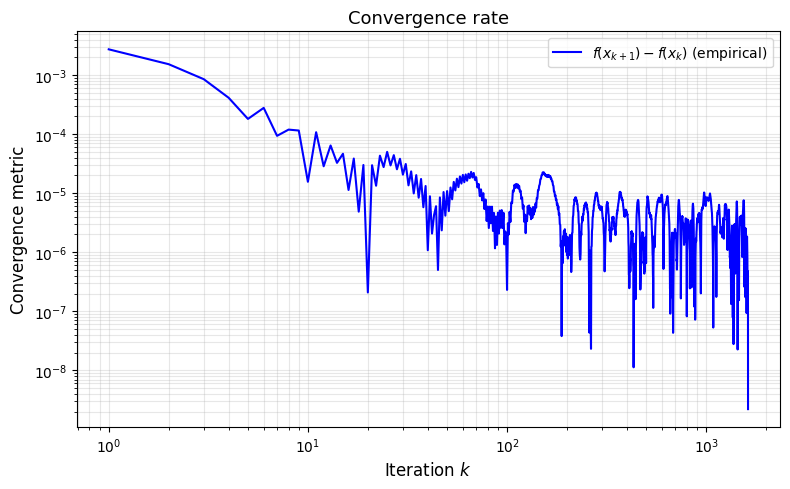

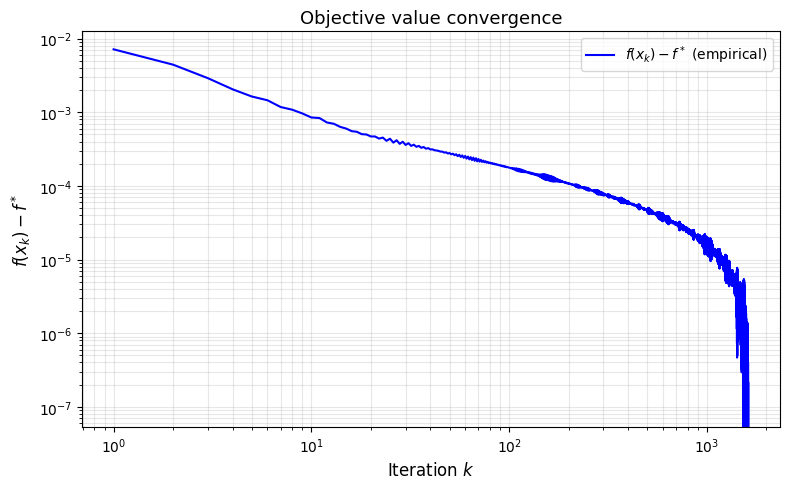

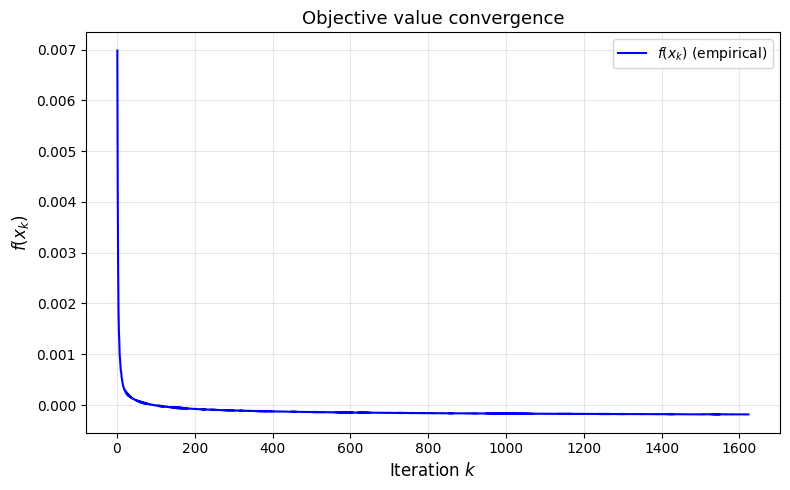

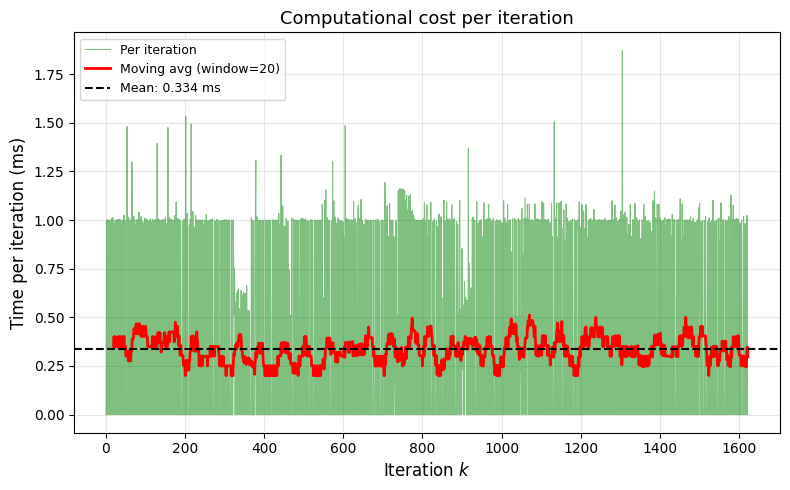

Total time: 0.5425 seconds
Total iterations: 1622
Final objective value: -0.000184
Average time per iteration: 0.3345 ms
Std time per iteration: 0.4714 ms


In [28]:

method = ProjectedSubgradientMethod({
    'step_size': 0.1,              # Initial step size α_0
    'step_size_rule': 'diminishing',  # α_k = α_0 / sqrt(k)
    'max_iter': 10000,
    'tol': 1e-8,
}, ValuePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0] , method ='random')

# Optimize portfolio on training data
result_ProjectedSubgradientMethod = method.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProjectedSubgradientMethod.keys())
print(f"Converged: {result_ProjectedSubgradientMethod['converged']}")
print(f"Iterations: {result_ProjectedSubgradientMethod['iterations']}")
print(f"Final objective value: {result_ProjectedSubgradientMethod['value']:.6f}")
print(result_ProjectedSubgradientMethod['obj_value'][-1])
print(result_ProjectedSubgradientMethod['value'])

# Plot convergence
plot_convergence(result_ProjectedSubgradientMethod , method_name="Projected_Subgradient_Method" , save_dir="../figures" , metric_used='function')

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 71
Final objective value: -0.000242

--- Comparison ---
Subgradient final value: -0.000184
Proximal final value:    -0.000242
Difference: 5.82e-05


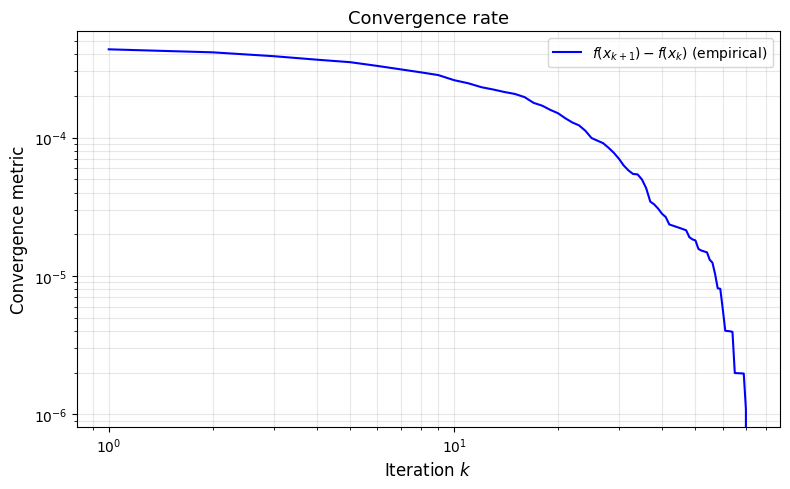

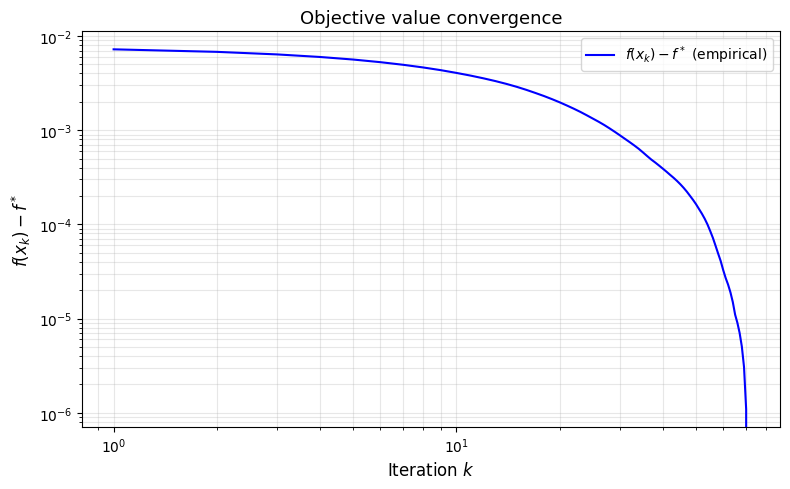

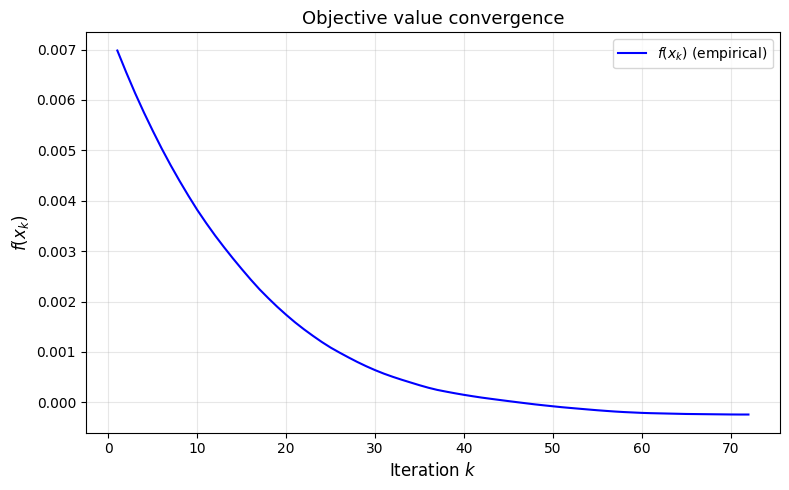

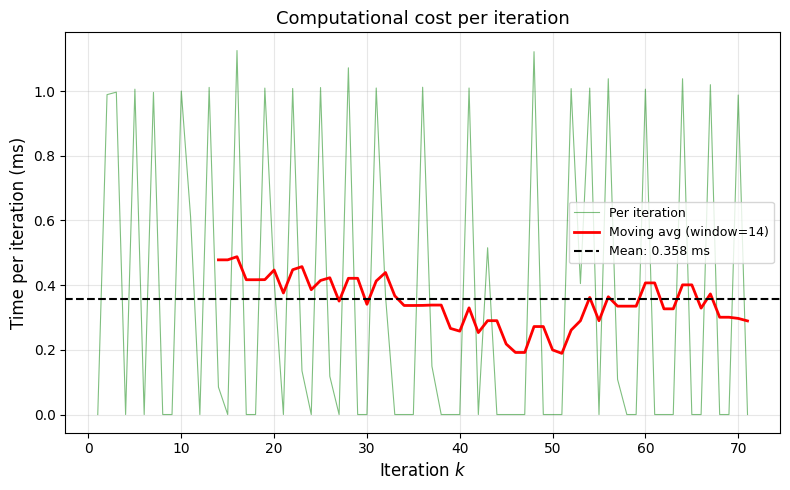

Total time: 0.0254 seconds
Total iterations: 71
Final objective value: -0.000242
Average time per iteration: 0.3577 ms
Std time per iteration: 0.4614 ms


In [29]:
# Proximal Gradient Method
# Use the SAME w0 as subgradient method for fair comparison

method_proximal = ProximalGradientMethod({
    'step_size': 0.01,           # Use 1/L for convergence guarantee
    'max_iter': 10000,
    'tol': 1e-8,
}, ValuePerformanceIndicator())

# Use the SAME w0 as the subgradient method (don't redefine it!)
result_ProximalGradient = method_proximal.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProximalGradient.keys())
print(f"Converged: {result_ProximalGradient['converged']}")
print(f"Iterations: {result_ProximalGradient['iterations']}")
print(f"Final objective value: {result_ProximalGradient['value']:.6f}")

# Compare with Subgradient
print(f"\n--- Comparison ---")
print(f"Subgradient final value: {result_ProjectedSubgradientMethod['value']:.6f}")
print(f"Proximal final value:    {result_ProximalGradient['value']:.6f}")
print(f"Difference: {abs(result_ProjectedSubgradientMethod['value'] - result_ProximalGradient['value']):.2e}")

# Plot convergence
plot_convergence(result_ProximalGradient, method_name="Proximal_Gradient_Method", save_dir="../figures", metric_used='function')

  tol=1.00e-02: 1 iterations
  tol=2.15e-03: 1 iterations
  tol=4.64e-04: 1 iterations
  tol=1.00e-04: 1 iterations
  tol=2.15e-05: 140 iterations
  tol=4.64e-06: 345 iterations
  tol=1.00e-06: 512 iterations
  tol=2.15e-07: 566 iterations
  tol=1.00e-06: 512 iterations
  tol=2.15e-07: 566 iterations
  tol=4.64e-08: 608 iterations
  tol=4.64e-08: 608 iterations
  tol=1.00e-08: 608 iterations
  tol=1.00e-08: 608 iterations


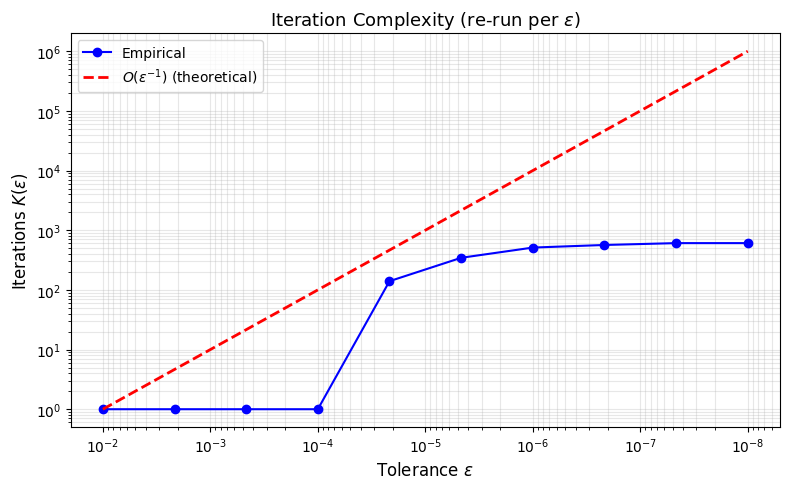

In [30]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-8

result_complexity = measure_iteration_complexity(
    method_class=ProximalGradientMethod,
    method_params={
        'step_size': 0.001,
        'max_iter': 10000,
        'tol': 1e-8,
    },
    model=model_non_smooth,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=1,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='ProximalGradientMethod',
    save_dir='../figures',
    metrics='function'
)

Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 57
Final objective value: -0.000242


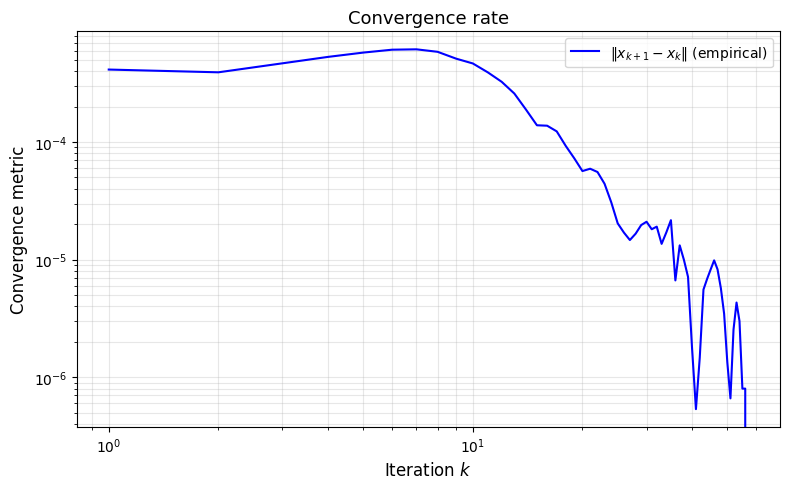

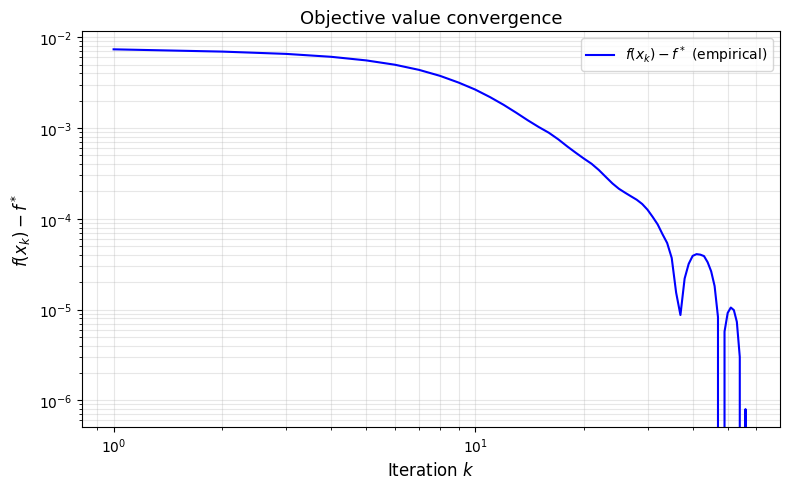

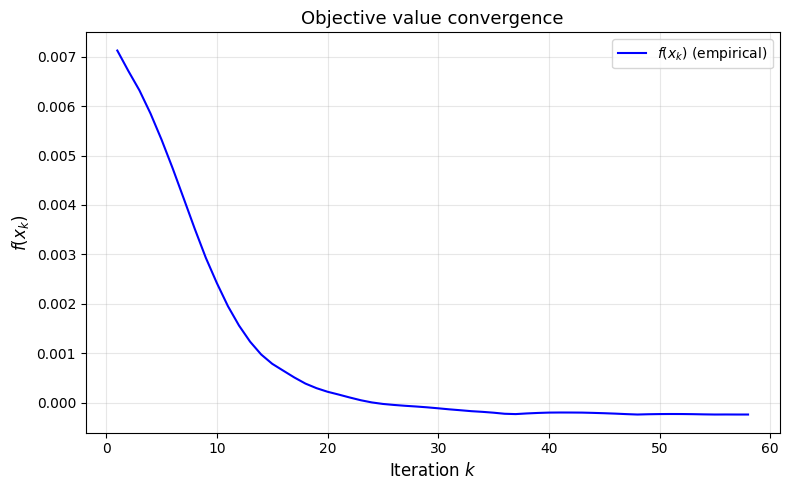

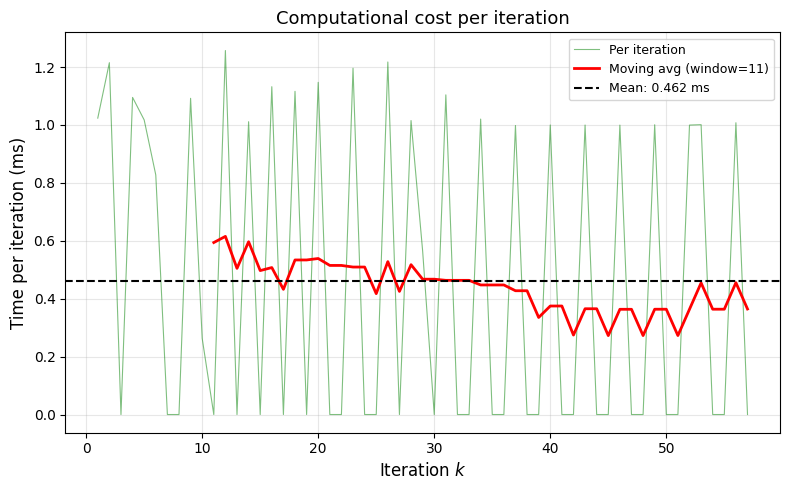

Total time: 0.0263 seconds
Total iterations: 57
Final objective value: -0.000242
Average time per iteration: 0.4617 ms
Std time per iteration: 0.5219 ms


In [31]:
# Constant step size only converges to a neighborhood of the optimum
method = ProximalGradientMethod_fast({
    'step_size': 0.01,              # Initial step size α_0
    'max_iter': 10000,
    'tol': 1e-25,
}, ValuePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0] , method="random")

# Optimize portfolio on training data
result_ProjectedSubgradientMethod = method.optimize(model_non_smooth, w0)

print("Keys disponibles:", result_ProjectedSubgradientMethod.keys())
print(f"Converged: {result_ProjectedSubgradientMethod['converged']}")
print(f"Iterations: {result_ProjectedSubgradientMethod['iterations']}")
print(f"Final objective value: {result_ProjectedSubgradientMethod['value']:.6f}")

# Plot convergence
plot_convergence(result_ProjectedSubgradientMethod)